# LeR with Custom Functions and Parameters

This notebook is created by [Phurailatpam Hemantakumar](https://hemantaph.com)

[![Documentation](https://img.shields.io/badge/ler-documentation-blue)](https://ler.hemantaph.com)

This notebook demonstrates how to customize the `LeR` class by defining custom source priors, lens parameter samplers, and detection criteria. We'll simulate both unlensed and lensed binary neutron star (BNS) events with fully custom configurations, then compare the results with default models.

---

## Table of Contents
1. [LeR initialization](#1-ler-initialization)
   - [1.1 Code snippet for initialization with default input arguments](#11-code-snippet-for-initialization-with-default-input-arguments)
   - [1.2 Initialize LeR with default settings](#12-initialize-ler-with-default-settings)
2. [Examine Available Prior Functions](#2-examine-available-prior-functions)
   - [2.1 Accessing functions as Class Attributes (Unlensed)](#21-accessing-functions-as-class-attributes-unlensed)
   - [2.2 Testing source related parameter prior functions](#22-testing-source-related-parameter-prior-functions)
   - [2.3 Accessing functions as Class Attributes (Lensed)](#23-accessing-functions-as-class-attributes-lensed)
   - [2.4 Accessing functions from the ler.gw_source_population module (Unlensed)](#24-accessing-functions-from-the-lergw_source_population-module-unlensed)
   - [2.5 Accessing functions from the ler.lens_galaxy_population module (Lensed)](#25-accessing-functions-from-the-lerlens_galaxy_population-module-lensed)
3. [Using Custom Functions in LeR Initialization](#3-using-custom-functions-in-ler-initialization)
   - [3.1 Custom Event Type with non-spinning configuration](#31-custom-event-type-with-non-spinning-configuration)
   - [3.2 Custom Merger Rate Density](#32-custom-merger-rate-density)
   - [3.3 Custom Source Frame Masses](#33-custom-source-frame-masses)
   - [3.4 Custom Lens Model](#34-custom-lens-model)
      - [3.4.1 Custom Velocity Dispersion](#341-custom-velocity-dispersion)
      - [3.4.2 Custom Axis Ratio](#342-custom-axis-ratio)
   - [3.5 Custom Detection Criteria](#35-custom-detection-criteria)
   - [3.6 LeR initialization with custom functions and parameters](#36-ler-initialization-with-custom-functions-and-parameters)
   - [3.7 Simulate Unlensed Population](#37-simulate-unlensed-population)
   - [3.8 Simulate Lensed Population](#38-simulate-lensed-population)
   - [3.9 Calculate Rates and Compare Results](#39-calculate-rates-and-compare-results)
4. [Compare Custom vs Default Models](#4-compare-custom-vs-default-models)
   - [4.1 Mass Distribution Comparison](#41-mass-distribution-comparison)
   - [4.2 Axis-Ratio Distribution Comparison](#42-axis-ratio-distribution-comparison)
5. [Summary](#5-summary)

---

## 1. LeR initialization 

### 1.1. Code snippet for initialization with default input arguments

```python
    from ler.rates import LeR
    import numpy as np
    import matplotlib.pyplot as plt
    from astropy.cosmology import LambdaCDM
    cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

    # Uncomment the below code if you need to change the default arguments.
    ler = LeR(
        # LeR setup arguments
        npool=4, # number of processors to use
        z_min=0.0, # minimum redshift
        z_max=10.0, # maximum redshift
        event_type='BBH', # event type
        lens_type = 'epl_shear_galaxy', # lens type
        cosmology=cosmo, # cosmology
        pdet_finder=None,  # if None, the pdet_finder will be calculated using the gwsnr package. 
        json_file_names=dict(
            ler_params="ler_params.json", # to store initialization parameters and important results
            unlensed_param="unlensed_param.json", # to store all unlensed events
            unlensed_param_detectable="unlensed_param_detectable.json", # to store only detectable unlensed events
            lensed_param="lensed_param.json", # to store all lensed events 
            lensed_param_detectable="lensed_param_detectable.json"), # to store only detectable lensed events
        interpolator_directory='./interpolator_json', # directory to store the interpolator pickle files. 'ler' uses interpolation to get values of various functions to speed up the calculations (relying on numba njit).
        ler_directory='./ler_data', # directory to store all the outputs
        verbose=True, # if True, will print all information at initialization

        # CBCSourceParameterDistribution class arguments
        gw_functions = dict(
            merger_rate_density = 'merger_rate_density_madau_dickinson_belczynski_ng', # function to calculate the merger rate density at a given redshift
            param_sampler_type = 'gw_parameters_rvs', # function to sample the source parameters. This will be used to sample the source parameters for all events (lensed and unlensed)
        ), 
        gw_functions_params = dict(
            merger_rate_density = dict(param_name='merger_rate_density', function_type='merger_rate_density_madau_dickinson_belczynski_ng', R0=1.9e-08, alpha_F=2.57, beta_F=5.83, c_F=3.36),
            param_sampler_type = None,
        ), 
        gw_priors = dict(
            zs = 'merger_rate_density_based_source_redshift',
            mass_1_source = 'broken_powerlaw_plus_2peaks',
            mass_ratio = 'powerlaw_with_smoothing',
            mass_2_source = None,
            geocent_time = 'uniform',
            ra = 'uniform',
            dec = 'sampler_cosine',
            phase = 'uniform',
            psi = 'uniform',
            theta_jn = 'sampler_sine',
            a_1 = 'uniform',
            a_2 = 'uniform',
            tilt_1 = None,
            tilt_2 = None,
            phi_12 = None,
            phi_jl = None,
        ),
        gw_priors_params = dict(
            zs = None,
            mass_1_source = dict(param_name='mass_1_source', sampler_type='broken_powerlaw_plus_2peaks', lam_0=0.361, lam_1=0.586, mpp_1=9.764, sigpp_1=0.649, mpp_2=32.763, sigpp_2=3.918, mlow_1=5.059, delta_m_1=4.321, break_mass=35.622, alpha_1=1.728, alpha_2=4.512, mmax=300.0, normalization_size=500),
            mass_ratio = dict(param_name='mass_ratio', sampler_type='powerlaw_with_smoothing', q_min=0.01, q_max=1.0, mlow_2=3.551, mmax=300.0, beta=1.171, delta_m=4.91, mmin=3.551),
            mass_2_source = None,
            geocent_time = dict(param_name='geocent_time', sampler_type='uniform', x_min=1238166018, x_max=1269702018),
            ra = dict(param_name='ra', sampler_type='uniform', x_min=0.0, x_max=6.283185307179586),
            dec = dict(param_name='dec', sampler_type='sampler_cosine', dec_min=-1.5707963267948966, dec_max=1.5707963267948966),
            phase = dict(param_name='phase', sampler_type='uniform', x_min=0.0, x_max=6.283185307179586),
            psi = dict(param_name='psi', sampler_type='uniform', x_min=0.0, x_max=3.141592653589793),
            theta_jn = dict(param_name='theta_jn', sampler_type='sampler_sine', theta_jn_min=0.0, theta_jn_max=3.141592653589793),
            a_1 = dict(param_name='a_1', sampler_type='uniform', x_min=-1.0, x_max=1.0),
            a_2 = dict(param_name='a_2', sampler_type='uniform', x_min=-1.0, x_max=1.0),
            tilt_1 = None,
            tilt_2 = None,
            phi_12 = None,
            phi_jl = None,
        ),
        spin_zero = False,
        spin_precession = False,

        # LensGalaxyParameterDistribution class arguments
        lens_functions = dict(
            param_sampler_type = 'epl_shear_sl_parameters_rvs',
            cross_section_based_sampler = 'importance_sampling_with_cross_section',
            optical_depth = 'optical_depth_numerical',
            cross_section = 'cross_section_epl_shear_interpolation',
        ),
        lens_functions_params = dict(
            param_sampler_type = None,
            cross_section_based_sampler = dict(n_prop_factor=10),
            optical_depth = None,
            cross_section = dict(num_th=500, maginf=-100.0),
        ),
        lens_param_samplers = dict(
            zs_sl = 'strongly_lensed_source_redshift',
            lens_redshift_sl = 'lens_redshift_strongly_lensed_numerical',
            lens_redshift = 'lens_redshift_intrinsic_numerical',
            velocity_dispersion = 'velocity_dispersion_ewoud',
            axis_ratio = 'rayleigh',
            axis_rotation_angle = 'uniform',
            external_shear1 = 'normal',
            external_shear2 = 'normal',
            density_profile_slope = 'normal',
        ),
        lens_param_samplers_params = dict(
            zs_sl = None,
            lens_redshift_sl = dict(integration_size=25000, use_multiprocessing=False),
            lens_redshift = None,
            velocity_dispersion = dict(sigma_min=100.0, sigma_max=400.0, alpha=0.94, beta=1.85, phistar=np.float64(0.02099), sigmastar=113.78),
            axis_ratio = dict(q_min=0.2, q_max=1.0),
            axis_rotation_angle = dict(x_min=0.0, x_max=6.283185307179586),
            external_shear1 = dict(mu=0.0, sigma=0.05, x_min=-np.inf, x_max=np.inf),
            external_shear2 = dict(mu=0.0, sigma=0.05, x_min=-np.inf, x_max=np.inf),
            density_profile_slope = dict(mu=1.99, sigma=0.149, x_min=-np.inf, x_max=np.inf),
        ),

        # ImageProperties class arguments
        n_min_images = 2,
        n_max_images = 4,
        time_window = 365. * 24. * 3600. * 1.,  # 1 year
        include_effective_parameters = False,
        lens_model_list = ['EPL_NUMBA', 'SHEAR'],
        image_properties_function = 'image_properties_epl_shear_njit',
        multiprocessing_verbose = True,
        include_redundant_parameters = False,

        # gwsnr package arguments
        snr_method = 'interpolation_aligned_spins',
        snr_type = 'optimal_snr',
        gwsnr_verbose = True,
        multiprocessing_verbose = True,
        pdet_kwargs = dict(
            snr_th = 10.0,
            snr_th_net = 10.0,
            pdet_type = 'boolean',
            distribution_type = 'noncentral_chi2',
            include_optimal_snr = False,
            include_observed_snr = False,
        ),
        mtot_min = 1.0,
        mtot_max = 500.0,
        ratio_min = 0.1,
        ratio_max = 1.0,
        spin_max = 0.99,
        mtot_resolution = 200,
        ratio_resolution = 20,
        spin_resolution = 10,
        batch_size_interpolation = 1000000,
        interpolator_dir = './interpolator_json',
        sampling_frequency = 2048.0,
        waveform_approximant = 'IMRPhenomD',
        frequency_domain_source_model = 'lal_binary_black_hole',
        minimum_frequency = 20.0,
        reference_frequency = None,
        duration_max = None,
        duration_min = None,
        fixed_duration = None,
        mtot_cut = False,
        psds = None,  # will consider the default bilby psds of 'L1', 'H1', 'V1'
        ifos = None,  # will consider the default bilby interferometer objects of 'L1', 'H1', 'V1'
        snr_recalculation = False,
        snr_recalculation_range = [6, 14],
        snr_recalculation_waveform_approximant = 'IMRPhenomXPHM',

        # common arguments, to generate interpolator
        create_new_interpolator = dict(
            velocity_dispersion = dict(create_new=False, resolution=200, zl_resolution=48),
            axis_ratio = dict(create_new=False, resolution=200, sigma_resolution=48),
            lens_redshift_sl = dict(create_new=False, resolution=16, zl_resolution=48),
            lens_redshift = dict(create_new=False, resolution=16, zl_resolution=48),
            optical_depth = dict(create_new=False, resolution=16),
            comoving_distance = dict(create_new=False, resolution=500),
            angular_diameter_distance = dict(create_new=False, resolution=500),
            angular_diameter_distance_z1z2 = dict(create_new=False, resolution=500),
            differential_comoving_volume = dict(create_new=False, resolution=500),
            zs_sl = dict(create_new=False, resolution=200),
            cross_section = dict(create_new=False, resolution=[25, 25, 45, 15, 15], spacing_config=dict(e1=dict(mode='two_sided_mixed_grid', power_law_part='lower', spacing_trend='increasing', power=2.5, value_transition_fraction=0.7, num_transition_fraction=0.9, auto_match_slope=True), e2=dict(mode='two_sided_mixed_grid', power_law_part='lower', spacing_trend='increasing', power=2.5, value_transition_fraction=0.7, num_transition_fraction=0.9, auto_match_slope=True), gamma=dict(mode='two_sided_mixed_grid', power_law_part='lower', spacing_trend='increasing', power=2.5, value_transition_fraction=0.7, num_transition_fraction=0.9, auto_match_slope=True), gamma1=dict(mode='two_sided_mixed_grid', power_law_part='lower', spacing_trend='increasing', power=2.5, value_transition_fraction=0.7, num_transition_fraction=0.9, auto_match_slope=True), gamma2=dict(mode='two_sided_mixed_grid', power_law_part='lower', spacing_trend='increasing', power=2.5, value_transition_fraction=0.7, num_transition_fraction=0.9, auto_match_slope=True))),
            merger_rate_density = dict(create_new=False, resolution=200),
            redshift_distribution = dict(create_new=False, resolution=200),
            luminosity_distance = dict(create_new=False, resolution=500),
            mass_1_source = dict(create_new=False, resolution=200),
            mass_ratio = dict(create_new=False, resolution=100, m1_resolution=200),
            mass_2_source = dict(create_new=False, resolution=200),
            geocent_time = dict(create_new=False, resolution=200),
            ra = dict(create_new=False, resolution=200),
            dec = dict(create_new=False, resolution=200),
            phase = dict(create_new=False, resolution=200),
            psi = dict(create_new=False, resolution=200),
            theta_jn = dict(create_new=False, resolution=200),
            a_1 = dict(create_new=False, resolution=200),
            a_2 = dict(create_new=False, resolution=200),
            tilt_1 = dict(create_new=False, resolution=200),
            tilt_2 = dict(create_new=False, resolution=200, tilt_1_resolution=100),
            phi_12 = dict(create_new=False, resolution=200),
            phi_jl = dict(create_new=False, resolution=200),
        ),
    )
```

### 1.2. Initialize LeR with default settings

Set `verbose=False` to suppress lengthy output

In [1]:
from ler import LeR
import numpy as np

# use this gwsnr's input args if you want SNR values in the output, besides the boolean detection probability values. This will increase the output dictionary size and the runtime of the code. For details, refer to https://gwsnr.hemantaph.com/examples/pdet_generation.html.:
# pdet_kwargs=dict(snr_th=10.0, snr_th_net=10.0, pdet_type="boolean", distribution_type="noncentral_chi2", include_optimal_snr=True, include_observed_snr=True)
ler = LeR(verbose=False)

---

## 2. Examine Available Prior Functions

There are two ways of accessing the built-in GW parameter prior functions and their default parameters. 

### 2.1. Accessing functions as Class Attributes (Unlensed)

In [2]:
# Display all available GW prior functions and sampler functions and their parameters
print("Built-in GW parameter functions and sampler functions and parameters:\n")
for func_name, func_params in ler.available_gw_functions.items():
    print(f"{func_name}:")
    
    if isinstance(func_params, dict):
        for param_name, param_value in func_params.items():
            print(f"  {param_name}: {param_value}")
    else:
        print(f"  {func_params}")
    print()

for func_name, func_params in ler.available_gw_prior.items():
    print(f"{func_name}:")
    
    if isinstance(func_params, dict):
        for param_name, param_value in func_params.items():
            print(f"  {param_name}: {param_value}")
    else:
        print(f"  {func_params}")
    print()

Built-in GW parameter functions and sampler functions and parameters:

merger_rate_density:
  merger_rate_density_madau_dickinson_belczynski_ng: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_madau_dickinson_belczynski_ng', 'R0': 1.9e-08, 'alpha_F': 2.57, 'beta_F': 5.83, 'c_F': 3.36}
  merger_rate_density_bbh_oguri2018: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_bbh_oguri2018', 'R0': 1.9e-08, 'b2': 1.6, 'b3': 2.1, 'b4': 30}
  merger_rate_density_madau_dickinson2014: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_madau_dickinson2014', 'R0': 8.9e-08, 'a': 0.015, 'b': 2.7, 'c': 2.9, 'd': 5.6}
  sfr_with_time_delay: {'param_name': 'merger_rate_density', 'function_type': 'sfr_with_time_delay', 'R0': 1.9e-08, 'a': 0.01, 'b': 2.6, 'c': 3.2, 'd': 6.2, 'td_min': 0.01, 'td_max': 10.0}
  merger_rate_density_bbh_popIII_ken2022: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_bbh_p

### 2.2. Testing source related parameter prior functions

In [3]:
# use the following code to inspect one of the merger rate density function
# print(ler.merger_rate_density_bbh_oguri2018.__doc__)

# Test one of the merger rate density function
print("\nTesting merger_rate_density_bbh_oguri2018 function")
zs =  np.array([0.1, 0.2, 0.3])
print(f"Redshifts: {zs}")
print(f"Merger Rate Denisty: {ler.merger_rate_density_bbh_oguri2018(zs)} Mpc^-3 yr^-1")


Testing merger_rate_density_bbh_oguri2018 function
Redshifts: [0.1 0.2 0.3]
merger_rate_density_bbh_oguri2018 interpolator will be generated at ./interpolator_json/merger_rate_density/merger_rate_density_bbh_oguri2018_2.json
Merger Rate Denisty: [2.21298914e-08 2.57321630e-08 2.98600744e-08] Mpc^-3 yr^-1


### 2.3. Accessing functions as Class Attributes (Lensed)

In [4]:
# Display all available lens parameter sampler functions and their parameters
print("Built-in lens parameter sampler functions and parameters:\n")
for func_name, func_params in ler.available_lens_priors.items():
    print(f"{func_name}:")
    
    if isinstance(func_params, dict):
        for param_name, param_value in func_params.items():
            print(f"  {param_name}: {param_value}")
    else:
        print(f"  {func_params}")
    print()

Built-in lens parameter sampler functions and parameters:

zs_sl:
  strongly_lensed_source_redshift: {'tau_approximation': True}

lens_redshift_sl:
  lens_redshift_strongly_lensed_sis_analytical: None
  lens_redshift_strongly_lensed_numerical: {'param_name': 'lens_redshift_sl', 'sampler_type': 'lens_redshift_strongly_lensed_numerical', 'lens_type': 'epl_shear_galaxy', 'integration_size': 25000, 'use_multiprocessing': False}

lens_redshift:
  lens_redshift_intrinsic_numerical: None

velocity_dispersion:
  gengamma: {'param_name': 'velocity_dispersion', 'sampler_type': 'gengamma', 'sigma_min': 100.0, 'sigma_max': 400.0, 'alpha': 0.94, 'beta': 1.85, 'phistar': np.float64(0.02099), 'sigmastar': 113.78}
  velocity_dispersion_choi: {'param_name': 'velocity_dispersion', 'sampler_type': 'velocity_dispersion_choi', 'sigma_min': 100.0, 'sigma_max': 400.0, 'alpha': 2.32, 'beta': 2.67, 'phistar': np.float64(0.0027439999999999995), 'sigmastar': 161.0}
  velocity_dispersion_bernardi: {'param_name': 

In [5]:
# use the following code to inspect one of the velocity dispersion sampler functions
# print(ler.gengamma.__doc__)

# Test one of the velocity dispersion sampler functions
print("\nTesting gengamma sampler function")
size = 5
print(f"Velocity dispersion: {ler.gengamma(size)} km/s")


Testing gengamma sampler function
gengamma interpolator will be generated at ./interpolator_json/velocity_dispersion/gengamma_1.json
Velocity dispersion: [121.01025904 124.90593863 186.82633715 113.61481765
 152.7145442 ] km/s


### 2.4. Accessing functions from the ler.gw_source_population module (Unlensed)

In [6]:
import ler.gw_source_population as gsp

for prior in gsp.available_prior_list():
    print(prior)

merger_rate_density_bbh_oguri2018_function
merger_rate_density_bbh_popIII_ken2022_function
merger_rate_density_madau_dickinson2014_function
merger_rate_density_madau_dickinson_belczynski_ng_function
merger_rate_density_bbh_primordial_ken2022_function
sfr_madau_fragos2017_with_bbh_td
sfr_madau_dickinson2014_with_bbh_td
sfr_madau_fragos2017_with_bns_td
sfr_madau_dickinson2014_with_bns_td
sfr_madau_fragos2017
sfr_madau_dickinson2014
ng2022_lognormal_joint_pdf
binary_masses_BBH_popIII_lognormal_rvs
binary_masses_BBH_primordial_lognormal_rvs
bimodal_pdf
binary_masses_BNS_bimodal_rvs
broken_powerlaw_pdf
gaussian_plus_isotropic_pdf
gaussian_plus_isotropic_joint_pdf
powerlaw_pdf
powerlaw_rvs
truncated_normal_pdf
truncated_normal_rvs
powerlaw_with_smoothing
powerlaw_plus_peak_pdf
powerlaw_plus_peak_function
powerlaw_plus_peak_rvs
broken_powerlaw_plus_2peaks_pdf
broken_powerlaw_plus_2peaks_function
broken_powerlaw_plus_2peaks_rvs
mass_ratio_powerlaw_with_smoothing_pdf
mass_ratio_powerlaw_with_sm

In [7]:
# use the following code to inspect one of the merger rate density function
# print(gsp.merger_rate_density_bbh_oguri2018.__doc__)

# Test one of the merger rate density function
print("\nTesting merger_rate_density_bbh_oguri2018 function")
zs =  np.array([0.1, 0.2, 0.3])
print(f"Redshifts: {zs}")
print(f"Merger Rate Denisty: {gsp.merger_rate_density_bbh_oguri2018_function(zs)} Mpc^-3 yr^-1")


Testing merger_rate_density_bbh_oguri2018 function
Redshifts: [0.1 0.2 0.3]
Merger Rate Denisty: [2.21298914e-08 2.57321630e-08 2.98600744e-08] Mpc^-3 yr^-1


### 2.5. Accessing functions from the ler.lens_galaxy_population module (Lensed)

In [8]:
import ler.lens_galaxy_population as lgp

for sampler in lgp.available_sampler_list():
    print(sampler)

lens_redshift_strongly_lensed_sis_analytical_pdf
lens_redshift_strongly_lensed_sis_analytical_rvs
velocity_dispersion_ewoud_denisty_function
velocity_dispersion_bernardi_denisty_function
gengamma_function
gengamma_pdf
gengamma_rvs
rayleigh_rvs
rayleigh_pdf
axis_ratio_padilla_strauss_rvs
axis_ratio_padilla_strauss_pdf
bounded_normal_sample
rejection_sampler
importance_sampler
importance_sampler_mp


In [9]:
# use the following code to inspect one of the velocity dispersion sampler functions
# print(lgp.gengamma_rvs.__doc__)

# Test one of the velocity dispersion sampler functions
print("\nTesting gengamma sampler function")
size = 5
print(f"Velocity dispersion: {lgp.gengamma_rvs(size)} km/s")


Testing gengamma sampler function
Velocity dispersion: [129.80469404 122.13905381 115.46994992 130.13669092
 178.38531492] km/s


---
---

## 3. Using Custom Functions in LeR Initialization

The `ler` package allows full customization of sampling functions and detection criteria. This section demonstrates a **Binary Neutron Star (BNS)** configuration with custom settings:

| Component | Custom Configuration | Default (BBH) |
| :--- | :--- | :--- |
| **Event Type** | BNS (non-spinning) | BBH (spinning, aligned) |
| **Merger Rate** | GWTC-3 based | GWTC-4 based |
| **Source Masses** | Uniform 1.0-2.5 $M_{\odot}$ | truncated normal |
| **Lens Model** | SIE (Singular Isothermal) | EPL+Shear |
| **Velocity Dispersion** | $\sigma_* = 161$ km/s | $\sigma_* = 113.78$ km/s |
| **Axis Ratio** | Padilla & Strauss (2008) | Rayleigh distribution |
| **Detectors** | 3G (ET, CE), $\rho_{\rm opt}$ > 12 | O4 (H1, L1, V1), $\rho_{\rm obs}$ > 10 |

**Notes:**

- **GW and Lens parameter priors/samplers** must be a function with `size` as the only input argument, or a `ler.utils.FunctionConditioning` class object (preferred for lens parameters). Use `numba.njit` decorator for prior/sampler functions when possible. `ler.utils.FunctionConditioning` creates interpolators for the custom functions to speed up the calculations relying on numba njit.

- **Merger rate density** must be a function of redshift, i.e., $F(z_s)$.

- **Velocity dispersion function (galaxy number density)** must be a function of velocity dispersion, i.e., $F(\sigma)$ or $F(\sigma, z_l)$.

### 3.1. Custom Event Type with non-spinning configuration

Using `event_type='BNS'` in the LeR class initialization will default to the following GW parameter priors corresponding to BNS. Other allowed event types are 'BBH' and 'NSBH'.

```python
    gw_functions = dict(
        merger_rate_density = 'merger_rate_density_madau_dickinson2014', 
    ),
    gw_functions_params = dict(
        merger_rate_density = dict(
            param_name='merger_rate_density', 
            function_type='merger_rate_density_madau_dickinson2014', 
            'R0': 89 * 1e-9, 'a': 0.015, 'b': 2.7, 'c': 2.9, 'd': 5.6
        ),
    ),
    gw_priors = dict(
        mass_1_source = 'truncated_normal',
        mass_2_source = 'truncated_normal',
        mass_ratio = None,
        a_1 = 'uniform',
        a_2 = 'uniform',
    ),
    gw_priors_params= dict(
        mass_1_source = dict(
            param_name='mass_1_source', sampler_type='truncated_normal',
            mu=1.4, sigma=0.68, x_min=1.0, x_max=2.5
        ),
        mass_2_source = dict(
            param_name='mass_2_source', sampler_type='truncated_normal',
            mu=1.4, sigma=0.68, x_min=1.0, x_max=2.5
        ),
        mass_ratio = None,
        a_1 = dict(
            param_name='a_1', sampler_type='uniform',
            xmin=-0.4, xmax=0.4
        ),
        a_2 = dict(
            param_name='a_2', sampler_type='uniform',
            xmin=-0.4, xmax=0.4
        ),
    ),
```

>> We will change some of these priors with our custom ones in the next sections.

For non-spinning configuration (for faster calculation in our example), we can set:

```python
    spin_zero=True,
    spin_precession=False,
```

### 3.2. Custom Merger Rate Density

Using the default BNS merger rate density prior model with the local merger rate density change from the default value of $R_0 = 89 \times 10^{-9} \, \text{Mpc}^{-3}\text{yr}^{-1}$ (GWTC-4) to $R_0 = 105.5 \times 10^{-9} \, \text{Mpc}^{-3}\text{yr}^{-1}$ (GWTC-3).

In [10]:
merger_rate_density_function = 'merger_rate_density_madau_dickinson2014'
merger_rate_density_input_args = dict(
    param_name='merger_rate_density',
    function_type='merger_rate_density_madau_dickinson2014',
    R0=105.5e-9, 
    a=0.015, 
    b=2.7, 
    c=2.9, 
    d=5.6,
)

print("Merger rate density function:", merger_rate_density_function)
print("Parameters:", merger_rate_density_input_args)

Merger rate density function: merger_rate_density_madau_dickinson2014
Parameters: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_madau_dickinson2014', 'R0': 1.055e-07, 'a': 0.015, 'b': 2.7, 'c': 2.9, 'd': 5.6}


### 3.3. Custom Source Frame Masses ($m_1^{src}$, $m_2^{src}$)

Using a uniform distribution to sample the binary masses mass_1_source and mass_2_source. Swapping of values if mass_1_source < mass_2_source will be done internally.

>> **Note**: Alternatively, in `LeR` initialization, you can provide `mass_ratio` instead of `mass_2_source`. In that case, `mass_2_source` will be internally calculated as `mass_1_source * mass_ratio`.

In [11]:
import numpy as np
from numba import njit

mmin=1.0
mmax=2.5

# define your custom function
# it should have 'size' as the only argument
# the same function will be used to sample both mass_1_source and mass_2_source. The code will swap the values if mass_1_source < mass_2_source.
@njit
def source_frame_masses_uniform(size):
    """
    Function to sample mass1 or mass2 from a uniform distribution between mmin and mmax.

    Parameters
    ----------
    size : `int`
        Number of samples to draw

    Returns
    -------
    mass_source : `numpy.ndarray`
        Array of mass samples in the source frame (Msun)
    """

    mass_source = np.random.uniform(mmin, mmax, size)

    return mass_source

# test
mass_source = source_frame_masses_uniform(size=5)
print(f"mass: {mass_source} M_sun")

mass: [2.47554309 1.24614399 2.19106097 1.17291098 1.72856904] M_sun


### 3.4. Custom Lens Model

Using `lens_model='sie_galaxy'` in the `LeR` initialization will use the following default settings. Other allowed lens models are 'epl_shear_galaxy' and 'sis_galaxy'.

```python
lens_priors = dict(
    zs_sl="strongly_lensed_source_redshift",
    lens_redshift_sl="lens_redshift_strongly_lensed_numerical",
    lens_redshift="lens_redshift_intrinsic_numerical",
    velocity_dispersion="velocity_dispersion_ewoud",
    axis_ratio="rayleigh",
    axis_rotation_angle="uniform",
    external_shear1="constant_values_n_size",
    external_shear2="constant_values_n_size",
    density_profile_slope="constant_values_n_size",
    external_shear1_sl="constant_values_n_size",
    external_shear2_sl="constant_values_n_size",
    density_profile_slope_sl="constant_values_n_size",
)
lens_priors_params = dict(
    zs_sl=None,
    lens_redshift_sl=dict(
        param_name = "lens_redshift_sl",
        sampler_type = "lens_redshift_strongly_lensed_numerical",
        lens_type = 'sie_galaxy',
        integration_size=25000, use_multiprocessing=False
    ),
    lens_redshift=None,
    velocity_dispersion=dict(
        param_name='velocity_dispersion', sampler_type='velocity_dispersion_ewoud',
        sigma_min=100.0,
        sigma_max=400.0,
        alpha=0.94,
        beta=1.85,
        phistar=2.099e-2 * (self.cosmo.h/0.7)**3,
        sigmastar=113.78,
    ),
    axis_ratio=dict(
        param_name='axis_ratio', sampler_type='rayleigh',
        q_min=0.2, q_max=1.0
    ),
    axis_rotation_angle=dict(
        param_name='axis_rotation_angle', sampler_type='uniform',
        x_min=0.0, x_max=2 * np.pi
    ),
    external_shear1=dict(param_name='external_shear1', sampler_type= 'constant_values_n_size', value=0.0),
    external_shear2=dict(param_name='external_shear2', sampler_type= 'constant_values_n_size', value=0.0),
    density_profile_slope=dict(param_name='density_profile_slope', sampler_type='constant_values_n_size', value=2.0),
    external_shear1_sl=dict(param_name='external_shear1_sl', sampler_type= 'constant_values_n_size', value=0.0),
    external_shear2_sl=dict(param_name='external_shear2_sl', sampler_type= 'constant_values_n_size', value=0.0),
    density_profile_slope_sl=dict(param_name='density_profile_slope', sampler_type='constant_values_n_size', value=2.0),
)
lens_functions = dict(
    param_sampler_type="epl_shear_sl_parameters_rvs",
    cross_section_based_sampler="importance_sampling_with_cross_section",
    optical_depth="optical_depth_numerical",
    cross_section="cross_section_sie_feixu",
)
lens_functions_params = dict(
    param_sampler_type=None,
    cross_section_based_sampler=dict(n_prop_factor=10),
    optical_depth=dict(param_name="optical_depth", function_type="optical_depth_numerical"),
    cross_section=None,
)
```

>> We will change the velocity dispersion and axis ratio samplers to our custom functions.

#### 3.4.1. Custom Velocity Dispersion

Unlike other lens parameter, custom velocity dispersion needs to be a density function (galaxy number density as a function of velocity dispersion).

In [19]:
from numba import njit
from ler.lens_galaxy_population import velocity_dispersion_ewoud_denisty_function

print("Velocity dispersion density function:")
print(velocity_dispersion_ewoud_denisty_function.__doc__)

velocity_dispersion_args = dict(
    param_name='velocity_dispersion',
    sampler_type='velocity_dispersion_ewoud',
    sigma_min=100.,  # default ler sigma_min=100 km/s
    sigma_max=400.,  # default ler sigma_max=400 km/s
    alpha=0.94,
    beta=1.85,
    phistar=2.099e-2,
    sigmastar=161.0,
)
alpha = float(velocity_dispersion_args["alpha"])
beta = float(velocity_dispersion_args["beta"])
phistar = float(velocity_dispersion_args["phistar"])
sigmastar = float(velocity_dispersion_args["sigmastar"])

sigma_object = njit(
    lambda sigma, zl: velocity_dispersion_ewoud_denisty_function(  # noqa: E731
        sigma,
        zl,
        alpha=alpha,
        beta=beta,
        phistar=phistar,
        sigmastar=sigmastar,
    )
)

# Test
sigma = np.array([100., 200., 300.])
zl = np.array([0.1, 0.2, 0.3])
print(f"Velocity dispersions: {sigma} km/s at lens redshifts: {zl}")
print(f"Velocity dispersion density function values: {sigma_object(sigma, zl)} Mpc^-3")

Velocity dispersion density function:

    Calculate the lens galaxy velocity dispersion function at redshift z (Oguri et al. (2018b) + Wempe et al. (2022)).

    Parameters
    ----------
    sigma : ``numpy.ndarray``
        Velocity dispersion of the lens galaxy (km/s).
    z : ``float``
        Redshift of the lens galaxy.
    alpha : ``float``
        Shape parameter of the velocity dispersion function. 

        default: 0.94
    beta : ``float``
        Slope parameter of the velocity dispersion function. 

        default: 1.85
    phistar : ``float``
        Normalization of the velocity dispersion function (Mpc^-3). 

        default: 2.099e-2
    sigmastar : ``float``
        Characteristic velocity dispersion (km/s). 

        default: 113.78

    Returns
    -------
    result : ``numpy.ndarray``
        Velocity dispersion function values. 

        Negative values are clipped to 0.
    
Velocity dispersions: [100. 200. 300.] km/s at lens redshifts: [0.1 0.2 0.3]
Velocity

>> It is recommended to use `ler.utils.FunctionConditioning` class object for custom lens parameter samplers, as it creates interpolators for the custom functions to speed up the calculations relying on numba njit.

Uncomment and run the following if you want to use `ler.utils.FunctionConditioning` class object.

In [18]:
# import numpy as np
# from ler.utils import FunctionConditioning, generate_mixed_grid
# # import number density function wrt velocity dispersion and redshift
# from ler.lens_galaxy_population import velocity_dispersion_ewoud_denisty_function

# velocity_dispersion_args = dict(
#     sigma_min=100,  # default ler sigma_min=100 km/s
#     sigma_max=400,  # default ler sigma_max=400 km/s
#     alpha=0.94,
#     beta=1.85,
#     phistar=2.099e-2,
#     sigmastar=161.0,
# )

# # identifier_dict dict allows for easy tracking of the generated interpolator in future usage
# identifier_dict = {"name": "velocity_dispersion_custom"}
# identifier_dict["sigma_min"] = velocity_dispersion_args["sigma_min"]
# identifier_dict["sigma_max"] = velocity_dispersion_args["sigma_max"]
# identifier_dict["resolution"] = 500
# identifier_dict["zl_resolution"] = 48

# # setting up inputs for the interpolator
# # Note: sigma_array and zl_array will form a 2D grid where the function is evaluated. Gird points are use for cubic spline interpolation.
# sigma_array = np.linspace(
#     identifier_dict["sigma_min"],
#     identifier_dict["sigma_max"],
#     identifier_dict["resolution"],
# )
# z_min = 0.001
# z_max = 10.0
# z_resolution = identifier_dict["zl_resolution"]
# zl_array = generate_mixed_grid(z_min, z_max, z_resolution)

# # define the function
# number_density_function = lambda sigma, zl: velocity_dispersion_ewoud_denisty_function(  # noqa: E731
#     sigma,
#     zl,
#     alpha=velocity_dispersion_args["alpha"],
#     beta=velocity_dispersion_args["beta"],
#     phistar=velocity_dispersion_args["phistar"],
#     sigmastar=velocity_dispersion_args["sigmastar"],
# )

# sigma_object = FunctionConditioning(
#     function=number_density_function,
#     x_array=sigma_array,
#     conditioned_y_array=zl_array,
#     identifier_dict=identifier_dict,
#     directory="./interpolator_json",
#     sub_directory="velocity_dispersion",
#     name=identifier_dict["name"],
#     create_new=False,
#     create_function_inverse=False,
#     create_function=True,
#     create_pdf=True,
#     create_rvs=True,
#     callback="rvs",
# )

# # Test
# sigma = np.array([100., 200., 300.])
# zl = np.array([0.1, 0.2, 0.3])
# print(f"Velocity dispersions: {sigma} km/s at lens redshifts: {zl}")
# print(f"Velocity dispersion density function values: {sigma_object.function(sigma, zl)} Mpc^-3")
# print(f"Random velocity dispersion samples: {sigma_object.rvs(len(zl), zl)} Mpc^-3")

### 3.4.2. Custom Axis Ratio

In [22]:
from scipy.interpolate import CubicSpline  # noqa: E402
from ler.utils import inverse_transform_sampler  # noqa: E402
from numba import njit  # noqa: E402

from ler.utils import FunctionConditioning

axis_ratio_args = dict(
    param_name='axis_ratio',
    sampler_type='axis_ratio_padilla_strauss_2008',
    q_min=0.2,
    q_max=1.0,
)

# Using Padilla and Strauss 2008 distribution for axis ratio
q_array = np.array(
    [0.04903276402927845,0.09210526315789469,0.13596491228070173,0.20789473684210524,0.2899703729522482,0.3230132450331126,0.35350877192982455,0.37946148483792264,0.4219298245614036,0.4689525967235971,0.5075026141512723,0.5226472638550018,0.5640350877192983,0.6096491228070177,0.6500000000000001,0.6864848379226213,0.7377192982456142,0.7787295224817011,0.8007581038689441,0.822786685256187,0.8668438480306729,0.8973684210526317,0.9254385964912283,
    ]
)
pdf = np.array(
    [0.04185262687135349,0.06114520695141845,0.096997499638376,0.1932510900336828,0.39547914337673706,0.49569751276216234,0.6154609137685201,0.7182049959882812,0.920153741243567,1.1573982157399754,1.3353263628106684,1.413149656448315,1.5790713532948977,1.7280185150744938,1.8132994441344819,1.8365803753840484,1.8178662203211204,1.748929843583365,1.688182592496342,1.6274353414093188,1.4948487090314488,1.402785526832393,1.321844068356993,
    ]
)

# Interpolate the pdf
spline = CubicSpline(q_array, pdf, extrapolate=True)
q_array = np.linspace(axis_ratio_args['q_min'], axis_ratio_args['q_max'], 500)
pdf = np.clip(spline(q_array), 0.0, None)

cdf_values = np.cumsum(pdf)
cdf_values /= cdf_values[-1]  # normalize


def q_rvs(size):
    return inverse_transform_sampler(size, cdf_values, q_array)


def q_pdf(q):
    return np.clip(spline(q), 0.0, None)


# FunctionConditioning provides both `.rvs` and `.pdf` (required by lens sampling)
q_object = FunctionConditioning(
    function=None,
    x_array=None,
    create_rvs=q_rvs,
    create_pdf=q_pdf,
    callback="rvs",
)

# test
q_samples = q_object(5)
print(f"Axis ratio samples: {q_samples}")
print(f"Axis ratio pdf values: {q_object.pdf(q_samples)}")

Axis ratio samples: [0.62782212 0.39753573 0.46666496 0.81924579 0.79105449]


>> It is recommended to use `ler.utils.FunctionConditioning` class object for custom lens parameter samplers, as it creates interpolators for the custom functions to speed up the calculations relying on numba njt.

Uncomment and run the following if you want to use `ler.utils.FunctionConditioning` class object.

In [ ]:
# from scipy.interpolate import CubicSpline  # noqa: E402
# from ler.utils import FunctionConditioning  # noqa: E402

# axis_ratio_args = dict(
#     q_min=0.2,
#     q_max=1.0,
# )

# identifier_dict = {"name": "axis_ratio_padilla_strauss_custom"}
# identifier_dict["q_min"] = axis_ratio_args["q_min"]
# identifier_dict["q_max"] = axis_ratio_args["q_max"]
# identifier_dict["resolution"] = 500

# # Using Padilla and Strauss 2008 distribution for axis ratio
# q_array = np.array(
#     [0.04903276402927845,0.09210526315789469,0.13596491228070173,0.20789473684210524,0.2899703729522482,0.3230132450331126,0.35350877192982455,0.37946148483792264,0.4219298245614036,0.4689525967235971,0.5075026141512723,0.5226472638550018,0.5640350877192983,0.6096491228070177,0.6500000000000001,0.6864848379226213,0.7377192982456142,0.7787295224817011,0.8007581038689441,0.822786685256187,0.8668438480306729,0.8973684210526317,0.9254385964912283,
#     ]
# )
# pdf = np.array(
#     [0.04185262687135349,0.06114520695141845,0.096997499638376,0.1932510900336828,0.39547914337673706,0.49569751276216234,0.6154609137685201,0.7182049959882812,0.920153741243567,1.1573982157399754,1.3353263628106684,1.413149656448315,1.5790713532948977,1.7280185150744938,1.8132994441344819,1.8365803753840484,1.8178662203211204,1.748929843583365,1.688182592496342,1.6274353414093188,1.4948487090314488,1.402785526832393,1.321844068356993,
#     ]
# )

# # Interpolate the pdf
# spline = CubicSpline(q_array, pdf, extrapolate=True)
# q_array = np.linspace(identifier_dict["q_min"], identifier_dict["q_max"], identifier_dict["resolution"])
# pdf = spline(q_array)

# q_object = FunctionConditioning(
#     function=pdf,  # it also allows precomputed values, besides function
#     x_array=q_array,
#     conditioned_y_array=None,
#     identifier_dict=identifier_dict,
#     directory="./interpolator_json",
#     sub_directory="axis_ratio",
#     name="axis_ratio_padilla_strauss",
#     create_new=False,
#     create_function_inverse=False,
#     create_function=True,
#     create_pdf=True,
#     create_rvs=True,
#     callback="rvs",
# )

# # test
# # sampling
# q_samples = q_object.rvs(5)
# print(f"Axis ratio samples: {q_samples}")
# # pdf
# q_pdf = q_object.pdf(q_samples)
# print(f"Axis ratio pdf values: {q_samples}")

axis_ratio_padilla_strauss interpolator will be generated at ./interpolator_json/axis_ratio/axis_ratio_padilla_strauss_1.json
Axis ratio samples: [0.92750867 0.31238047 0.67003542 0.551374   0.45404884]
Axis ratio pdf values: [0.92750867 0.31238047 0.67003542 0.551374   0.45404884]


### 3.5. Custom Detection Criteria

Custom pdet_finder should be of this format:

```python
    def custom_pdet_finder(gw_param_dict):
        """
        Parameters
        ----------
        gw_param_dict: dict
            Dictionary containing the GW parameters of the event.

        Returns
        -------
        pdet_dict: dict
            Dictionary with key 'pdet_net'.
```

- For our example, we will use 3G detectors (Einstein Telescope and Cosmic Explorer) with SNR threshold of 12.

>> **Note**: Even though `ler` uses `pdet_net` to determine detectability, we can use standard SNR (or other detector sensitivity arguments) instead, and set a corresponding threshold later. 

In [28]:
# Define a function that sets detection criteria
from gwsnr import GWSNR

# 3G detectors: Einstein Telescope (ET) and Cosmic Explorer (CE)
mmin, mmax = 1.0, 2.5
zmin, zmax = 0.0, 10.0

gwsnr_3g = GWSNR(
    npool=4,
    ifos=['ET', 'CE'],  # 3G detector network
    snr_method='interpolation_no_spins',  # BNS have no spins
    mtot_min=2*mmin*(1+zmin), mtot_max=2*mmax*(1+zmax),
    sampling_frequency=2048.0, waveform_approximant='IMRPhenomD',
    minimum_frequency=20.0, gwsnr_verbose=False,
)

detection_threshold=12

def detection_criteria(gw_param_dict):
    """
    Custom detection criteria for 3G detectors with optimal SNR as output.
    """

    dict_ = {}
    dict_['pdet_net'] = gwsnr_3g.optimal_snr(gw_param_dict=gw_param_dict)['optimal_snr_net'] 
    return dict_

# test
gw_param_dict = dict(
    mass_1 = np.array([20.0, 20.0]),
    mass_2 = np.array([10.0, 10.0]),
    luminosity_distance = np.array([1000.0, 40000.0]),
)
detection_dict = detection_criteria(gw_param_dict)
print(f"SNR results: {detection_dict}")
pdet_net = detection_dict['pdet_net']>= detection_threshold
print(f"Detection results: {pdet_net}")


Initializing GWSNR class...

Interpolator will be loaded for ET1 detector from ./interpolator_json/ET1/partialSNR_dict_0.json
Interpolator will be loaded for ET2 detector from ./interpolator_json/ET2/partialSNR_dict_0.json
Interpolator will be loaded for ET3 detector from ./interpolator_json/ET3/partialSNR_dict_0.json
Interpolator will be loaded for CE detector from ./interpolator_json/CE/partialSNR_dict_0.json


SNR results: {'pdet_net': array([408.62083928,  10.21552098])}
Detection results: [ True False]


### 3.6. LeR initialization with custom functions and parameters 

Create a `LeR` instance with custom source priors, lens samplers, and detection criteria for BNS events.

In [29]:
from ler import LeR

ler = LeR(
    # Core setup
    npool=6, 
    event_type='BNS', 
    lens_type='sie_galaxy',
    
    # Source priors
    gw_functions=dict(
        merger_rate_density=merger_rate_density_function,
    ),
    gw_functions_params=dict(
        merger_rate_density=merger_rate_density_input_args,
    ),
    gw_priors=dict(
        mass_1_source=source_frame_masses_uniform,
        mass_2_source=source_frame_masses_uniform,
    ),
    gw_priors_params=dict(
        mass_1_source=dict(
            param_name='mass_1_source',
            sampler_type='source_frame_masses_uniform',
            mmin=1.0,
            mmax=2.5,
        ),
        mass_2_source=dict(
            param_name='mass_2_source',
            sampler_type='source_frame_masses_uniform',
            mmin=1.0,
            mmax=2.5,
        ),
    ),
    
    # Lens samplers
    lens_priors=dict(
        velocity_dispersion=sigma_object,
        axis_ratio=q_object,
    ),
    lens_priors_params=dict(
        velocity_dispersion=velocity_dispersion_args,
        axis_ratio=axis_ratio_args,
    ),
    
    # Custom detection
    pdet_finder=detection_criteria,
    ler_directory='./ler_data_custom',
)


Initializing LeR class...


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ./interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using user provided custom velocity_dispersion function
velocity_dispersion_custom interpolator will be generated at ./interpolator_json/velocity_dispersion/velocity_dispersion_custom_3.json
using user provided custom axis_ratio sampler function
using ler available axis_rotation_angle function : uniform
using ler available density_profile_slop

### 3.7. Simulate Unlensed Population

Generate unlensed BNS events using the custom mass distribution and merger rate density.

In [30]:
unlensed_params = ler.unlensed_cbc_statistics(size=100000, batch_size=50000, resume=False)

print(f"\nTotal unlensed events simulated: {len(unlensed_params['zs'])}")
print(f"Sample source redshift values (first 5): {unlensed_params['zs'][:5]}")
print(f"Sample masses (first 3):")
print(f"  mass_1: {unlensed_params['mass_1_source'][:3]}")
print(f"  mass_2: {unlensed_params['mass_2_source'][:3]}")

unlensed params will be stored in ./ler_data_custom/unlensed_param.json
removing ./ler_data_custom/unlensed_param.json if it exists
Batch no. 1
sampling gw source params...
calculating pdet...
Batch no. 2
sampling gw source params...
calculating pdet...
saving all unlensed parameters in ./ler_data_custom/unlensed_param.json 

Total unlensed events simulated: 100000
Sample source redshift values (first 5): [2.57179313 0.44740802 1.35452178 1.11470706 4.19621209]
Sample masses (first 3):
  mass_1: [2.23496178 1.10452232 2.05232208]
  mass_2: [2.08128978 1.9367126  1.8850276 ]


### 3.8. Simulate Lensed Population

Generate lensed BNS events with custom lens parameters.

In [31]:
lensed_params = ler.lensed_cbc_statistics(size=100000, batch_size=50000, resume=False)

print(f"\nTotal lensed events simulated: {len(lensed_params['zs'])}")
print(f"Sample source redshift values (first 5): {lensed_params['zs'][:5]}")
print(f"Lens parameters (first 3):")
lens_params = ['zl', 'sigma', 'q']
for param in lens_params:
    if param in lensed_params:
        print(f"  {param}: {lensed_params[param][:3]}")

lensed params will be stored in ./ler_data_custom/lensed_param.json
removing ./ler_data_custom/lensed_param.json if it exists
Batch no. 1
sampling lensed params...
sampling lens parameters with epl_shear_sl_parameters_rvs...
Invalid sample found. Resampling 3320 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
Invalid sample found. Resampling 243 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
Invalid sample found. Resampling 17 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
calculating pdet...
Batch no. 2
sampling lensed params...
sampling lens parameters with epl_shear_sl_parameters_rvs...
Invalid sample found. Resampling 3337 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
Invalid sample found. Resampling 226 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
Invalid sample found. Resampling 16 lensed events...
sampling lens parameters wi

In [32]:
# include other useful parameters in the output dictionary.
# It is omitted by default to save runtime and memory.
# For theta_E, n_images, mass_1, mass_2, luminosity_distance:
lensed_param = ler.recover_redundant_parameters(lensed_params)
# For effective_luminosity_distance, effective_geocent_time, effective_phase, effective_ra, effective_dec:
lensed_param = ler.produce_effective_params(lensed_param)

# or you can simply set 'include_redundant_parameters=True, include_effective_parameters=True' in the input args of LeR initialization to include these parameters in the output dictionary by default.

### 3.9. Calculate Rates and Compare Results

Calculate unlensed and lensed detection rates using the custom detection criteria.

In [33]:
# Calculate detection rates
rate_unlensed, unlensed_param_detectable = ler.unlensed_rate(
    unlensed_param=unlensed_params,
    pdet_threshold=detection_threshold
)
rate_lensed, lensed_param_detectable = ler.lensed_rate(
    lensed_param=lensed_params,
    pdet_threshold=[detection_threshold, detection_threshold], 
    num_img=[1, 1]
)
rate_ratio = ler.rate_ratio()

print(f"\n=== Detection Rates (BNS with Custom Configuration) ===")
print(f"Unlensed rate: {rate_unlensed:.4e} events/year")
print(f"Lensed rate:   {rate_lensed:.4e} events/year")
print(f"Rate ratio (lensed/unlensed): {rate_ratio:.4f}")

Using provided unlensed_param dict...
total unlensed rate (yr^-1): 102762.29092932232
number of simulated unlensed detectable events: 26143
number of simulated all unlensed events: 100000
storing detectable params in ./ler_data_custom/unlensed_param_detectable.json
Using provided lensed_param dict...
total lensed rate (yr^-1): 129.67953677564768
number of simulated lensed detectable events: 8622
number of simulated all lensed events: 100000
storing detectable params in ./ler_data_custom/lensed_param_detectable.json
unlensed_rate: 102762.29092932232
lensed_rate: 129.67953677564768
ratio: 792.4325879348753

=== Detection Rates (BNS with Custom Configuration) ===
Unlensed rate: 1.0276e+05 events/year
Lensed rate:   1.2968e+02 events/year
Rate ratio (lensed/unlensed): 792.4326


---

## 4. Compare Custom vs Internal Models

### 4.1. Mass Distribution Comparison

Compare the custom uniform mass distribution with an internal BNS mass model (normal distribution).

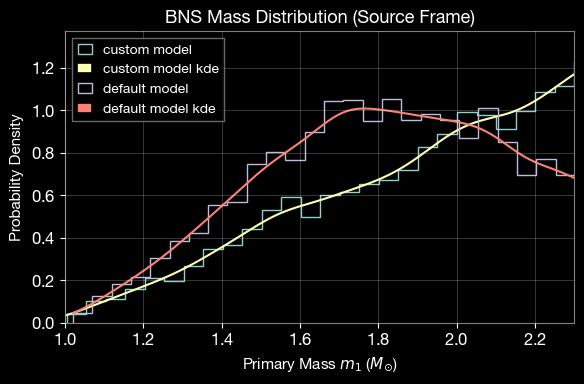

In [34]:
import ler.utils as lerplt
import matplotlib.pyplot as plt

# Custom mass distributions for comparison (uniform)
m1_custom = source_frame_masses_uniform(size=5000)
m2_custom = source_frame_masses_uniform(size=5000)
# swapping to ensure mass_1 >= mass_2
idx = m1_custom < m2_custom
m1_custom[idx], m2_custom[idx] = m2_custom[idx], m1_custom[idx]

# internal BNS normal distribution in LeR
kwargs = dict(
    param_name = "mass_1_source",
    sampler_type = "truncated_normal",
    mu=1.4, sigma=0.68, x_min=1.0, x_max=2.5
)
m1_default = ler.truncated_normal(size=5000, **kwargs)
m2_default = ler.truncated_normal(size=5000, **kwargs)
# swapping to ensure mass_1 >= mass_2
idx = m1_default < m2_default
m1_default[idx], m2_default[idx] = m2_default[idx], m1_default[idx]

custom_dict = dict(mass_1=m1_custom)
default_dict = dict(mass_1=m1_default)

# Plot comparison
plt.figure(figsize=(6, 4))
lerplt.param_plot(
    param_name="mass_1", 
    param_dict=custom_dict, # or the json file name
    plot_label='custom model',
);
lerplt.param_plot(
    param_name="mass_1", 
    param_dict=default_dict,
    plot_label='default model',
);
plt.xlabel(r'Primary Mass $m_1$ ($M_{\odot}$)', fontsize=11)
plt.ylabel(r'Probability Density', fontsize=11)
plt.title('BNS Mass Distribution (Source Frame)', fontsize=13, fontweight='bold')
plt.xlim(1.0, 2.3)
plt.grid(alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 4.2. Axis-Ratio Distribution Comparison

Compare the `ler` default axis-ratio distribution (Rayleigh distribution, Collet et al. 2018) with custom axis-ratio distribution (Padilla and Strauss 2008)

rayleigh interpolator will be generated at ./interpolator_json/axis_ratio/rayleigh_2.json


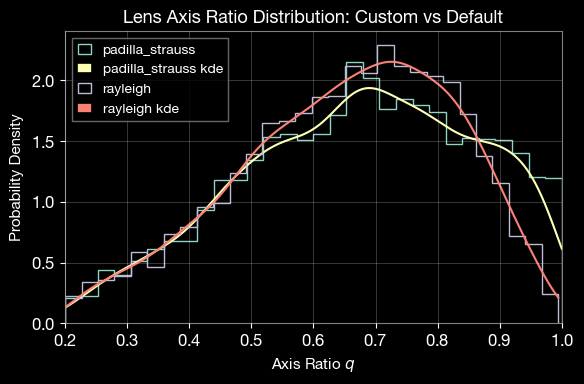

In [35]:
# Compare axis-ratio distributions
size = 5000
zl = np.ones(size)
sigma = ler.velocity_dispersion(size, zl)
rayleigh = ler.rayleigh(size, sigma)
padilla_strauss = q_object(size)

axis_ratio_dict = dict(rayleigh=rayleigh, padilla_strauss=padilla_strauss)

# Plot comparison
plt.figure(figsize=(6, 4))
lerplt.param_plot(
    param_name="padilla_strauss",
    param_dict=axis_ratio_dict,
    plot_label='padilla_strauss',
)
lerplt.param_plot(
    param_name="rayleigh",
    param_dict=axis_ratio_dict,
    plot_label='rayleigh',
)
plt.xlabel(r'Axis Ratio $q$', fontsize=11)
plt.ylabel(r'Probability Density', fontsize=11)
plt.title('Lens Axis Ratio Distribution: Custom vs Default', fontsize=13, fontweight='bold')
plt.xlim(0.2, 1.)
plt.grid(alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 5. Summary

This notebook demonstrated how to customize the `LeR` class for gravitational wave population studies:

- **Custom source priors**: Replaced the default BNS bimodal mass distribution with a uniform distribution
- **Custom merger rate density**: Modified the local merger rate density parameter
- **Custom lens parameters**: Implemented Padilla & Strauss (2008) axis-ratio distribution and modified velocity dispersion
- **Custom detection criteria**: Used 3G detectors (ET, CE) with SNR threshold of 12

These customizations enable flexible modeling of different astrophysical scenarios while leveraging `LeR`'s efficient sampling and rate calculation infrastructure.